# Capstone 2 
## 2. Data Wrangling: Instagram Dataset


## 2.1.  Import Libraries 

In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2.2 Load the data set 

In [4]:
# Read the Instagram Analytics Dataset 
insta_data = pd.read_csv('/Users/rupashree/Downloads/Instagram_Analytics.csv')

##  2.3 Dataset Overview

In this section, we check the number of rows & columns, data types, missingness and duplicates of the instagram dataset 

In [5]:
# Check the number of rows and columns 
insta_data.shape

(29999, 15)

In [6]:
# Check the columns 
insta_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   upload_date       29999 non-null  object 
 2   media_type        29999 non-null  object 
 3   likes             29999 non-null  int64  
 4   comments          29999 non-null  int64  
 5   shares            29999 non-null  int64  
 6   saves             29999 non-null  int64  
 7   reach             29999 non-null  int64  
 8   impressions       29999 non-null  int64  
 9   caption_length    29999 non-null  int64  
 10  hashtags_count    29999 non-null  int64  
 11  followers_gained  29999 non-null  int64  
 12  traffic_source    29999 non-null  object 
 13  engagement_rate   29999 non-null  float64
 14  content_category  29999 non-null  object 
dtypes: float64(1), int64(9), object(5)
memory usage: 3.4+ MB


In [7]:
# Call the head method on insta data to print first few several rows of data 
insta_data.head()

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology


In [8]:
# Count missing values in any columns 
missing_values = insta_data.isna().sum()
print(missing_values)

post_id             0
upload_date         0
media_type          0
likes               0
comments            0
shares              0
saves               0
reach               0
impressions         0
caption_length      0
hashtags_count      0
followers_gained    0
traffic_source      0
engagement_rate     0
content_category    0
dtype: int64


In [9]:
# Drop Duplicate rows
insta_df = insta_data.drop_duplicates()
insta_df.shape

(29999, 15)

## 2.4 Data types conversion

In [10]:
# Check the data types of columns
insta_df.dtypes

post_id              object
upload_date          object
media_type           object
likes                 int64
comments              int64
shares                int64
saves                 int64
reach                 int64
impressions           int64
caption_length        int64
hashtags_count        int64
followers_gained      int64
traffic_source       object
engagement_rate     float64
content_category     object
dtype: object

In [11]:
# Convert upload_date to datetime column 
insta_df['upload_date'] = pd.to_datetime(insta_df['upload_date'])
# Use insta data to select the columns of dtype object 
obj_col = ['post_id', 'media_type', 'traffic_source', 'content_category']
insta_df[obj_col] = insta_df[obj_col].astype('category')
insta_df.dtypes

post_id                   category
upload_date         datetime64[ns]
media_type                category
likes                        int64
comments                     int64
shares                       int64
saves                        int64
reach                        int64
impressions                  int64
caption_length               int64
hashtags_count               int64
followers_gained             int64
traffic_source            category
engagement_rate            float64
content_category          category
dtype: object

We apply a hybrid cleaning approach: remove rows that are logically impossible.

# 2.5 Descriptive Statistics

In [12]:
# Summary Statistics
insta_df.describe()

,upload_date,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,engagement_rate
count,29999,29999.000000,29999.000000,29999.000000,29999.000000,2.999900e+04,2.999900e+04,29999.000000,29999.000000,29999.000000,29999.000000
mean,2025-05-19 23:56:53.977950208,99912.661789,5017.781426,2502.912564,7490.124637,9.965616e+05,1.246669e+06,1103.110904,14.887430,502.152805,14.419276
min,2024-11-19 09:25:22.954916,7.000000,0.000000,0.000000,0.000000,1.650000e+02,5.107000e+03,0.000000,0.000000,0.000000,0.120000
25%,2025-02-18 09:25:22.954916096,49755.000000,2530.500000,1246.000000,3690.500000,4.936810e+05,7.469585e+05,555.000000,7.000000,251.000000,5.180000
50%,2025-05-19 09:25:22.954916096,99580.000000,5042.000000,2498.000000,7483.000000,9.921810e+05,1.241026e+06,1100.000000,15.000000,501.000000,9.190000
75%,2025-08-19 09:25:22.954916096,150225.000000,7518.000000,3768.000000,11294.000000,1.494798e+06,1.749264e+06,1656.000000,23.000000,755.000000,15.670000
max,2025-11-19 09:25:22.954916,200000.000000,10000.000000,5000.000000,15000.000000,1.999865e+06,2.497940e+06,2200.000000,30.000000,1000.000000,3259.820000
std,NaN,57905.967401,2888.404881,1448.320395,4352.546949,5.777906e+05,5.970924e+05,635.991308,9.005811,290.364038,29.660210


In [13]:
# Check the columns and values
insta_df.columns

Index(['post_id', 'upload_date', 'media_type', 'likes', 'comments', 'shares',
       'saves', 'reach', 'impressions', 'caption_length', 'hashtags_count',
       'followers_gained', 'traffic_source', 'engagement_rate',
       'content_category'],
      dtype='object')

# 2.6 Boxplot of columns from dataset

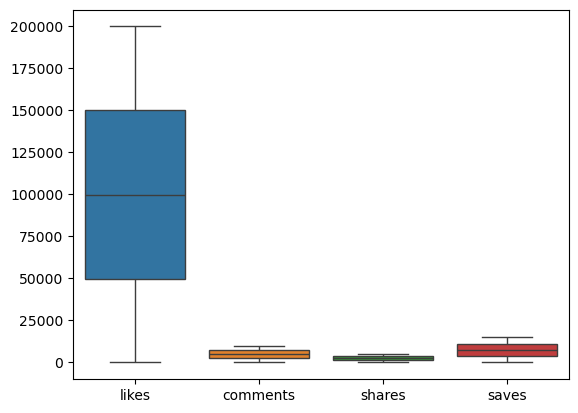

In [12]:
# Boxplot 
sns.boxplot(data = insta_df[['likes','comments', 'shares',
       'saves']])
plt.show()

<Axes: >

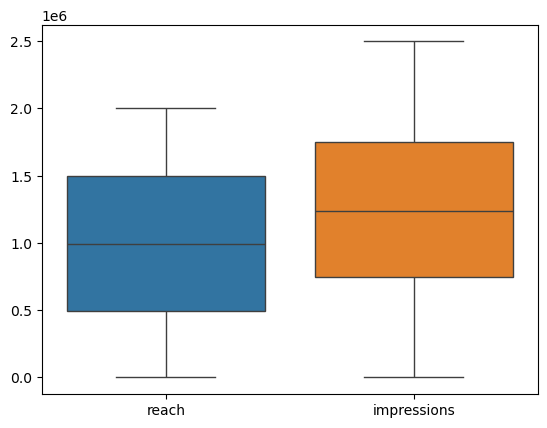

In [40]:
sns.boxplot(data = insta_df[['reach', 'impressions']])

<Axes: >

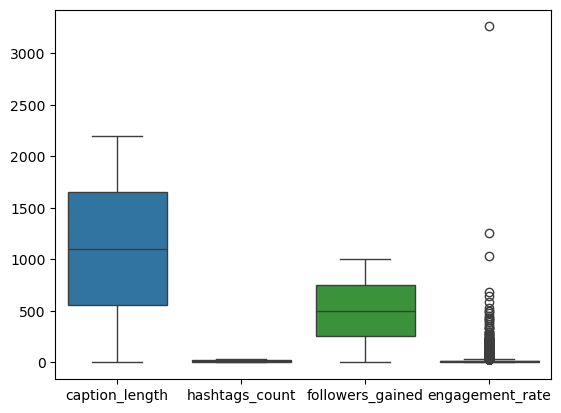

In [41]:
sns.boxplot(data = insta_df[['caption_length', 'hashtags_count','followers_gained','engagement_rate']])

Engagement rate have exceptionally high values. So, we have to dig deeper to check the data quality of our variable of interest. 

In [42]:
q1 = insta_df['engagement_rate'].quantile(0.25)
q3 = insta_df['engagement_rate'].quantile(0.75)
iqr = q3 - q1
lb = q1 -  1.5 * iqr
ub = q3 + 1.5 * iqr
print(lb, ub)

-10.555 31.405


In [46]:
eng_outliers = insta_df[insta_data['engagement_rate'] > ub]
eng_outliers

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
18,IG0000019,2025-06-20 09:25:22.954916,Photo,111231,6343,209,14970,61120,85737,2062,27,892,External,154.84,Lifestyle
21,IG0000022,2025-10-04 09:25:22.954916,Photo,179760,1745,4286,13818,57656,115755,401,2,742,Reels Feed,172.44,Fashion
25,IG0000026,2025-02-18 09:25:22.954916,Video,77071,2115,2268,5573,7054,26092,1067,29,243,Hashtags,333.54,Fashion
32,IG0000033,2025-04-17 09:25:22.954916,Reel,166153,994,4272,3066,30495,138675,984,21,882,Home Feed,125.82,Music
45,IG0000046,2025-07-29 09:25:22.954916,Video,199799,10000,4736,1895,287485,653395,874,23,924,Profile,33.12,Music
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29946,IG0029947,2025-10-22 09:25:22.954916,Carousel,124100,984,76,420,170020,353772,372,11,9,External,35.50,Comedy
29959,IG0029960,2025-09-25 09:25:22.954916,Reel,147950,4367,4157,4837,40876,490935,634,19,450,Home Feed,32.86,Comedy
29968,IG0029969,2025-02-17 09:25:22.954916,Video,95366,9272,1152,7956,188492,324231,908,0,660,Home Feed,35.08,Music
29975,IG0029976,2024-12-01 09:25:22.954916,Video,142193,4097,1438,4884,29813,99360,1305,29,256,Reels Feed,153.60,Fashion


We apply a hybrid cleaning approach: remove only rows that are logically impossible: likes > reach OR comments > reach OR saves > reach OR impression < reach. This keeps viral posts with unusually high impressions/reach ratios, but remove rows that cannot exist in real Instagram behaviour.

In [14]:
insta_df['invalid_metrics_flag'] = (
    (insta_df['likes'] > insta_df['reach']) |
    (insta_df['comments'] > insta_df['reach']) |
    (insta_df['saves'] > insta_df['reach']) |
    (insta_df['impressions'] < insta_df['reach'])
)
flagged_rows = insta_df[insta_df['invalid_metrics_flag']]
print(flagged_rows.head())
flagged_rows.shape

      post_id                upload_date media_type   likes  comments  shares  \
4   IG0000005 2025-03-21 09:25:22.954916      Video   99646      2703    4444   
18  IG0000019 2025-06-20 09:25:22.954916      Photo  111231      6343     209   
21  IG0000022 2025-10-04 09:25:22.954916      Photo  179760      1745    4286   
25  IG0000026 2025-02-18 09:25:22.954916      Video   77071      2115    2268   
32  IG0000033 2025-04-17 09:25:22.954916       Reel  166153       994    4272   

    saves  reach  impressions  caption_length  hashtags_count  \
4    9746   7004       495406            1905               8   
18  14970  61120        85737            2062              27   
21  13818  57656       115755             401               2   
25   5573   7054        26092            1067              29   
32   3066  30495       138675             984              21   

    followers_gained traffic_source  engagement_rate content_category  \
4                155        Profile            23

(1552, 16)

In [15]:
# Keep only valid rows
clean_insta_df = insta_df.loc[~insta_df['invalid_metrics_flag']].copy()
clean_insta_df.head()
clean_insta_df.shape

(28447, 16)

Now, we obtain clean data and removed rows that are logically impossible. This preserves viral posts and extreme but plausible behavior, while eliminating data errors that would disort EDA and modeling. This small removal percentage keeps the dataset robust for analysis while improving data quality and credibility. 

# 2.5 Correlation Analysis 

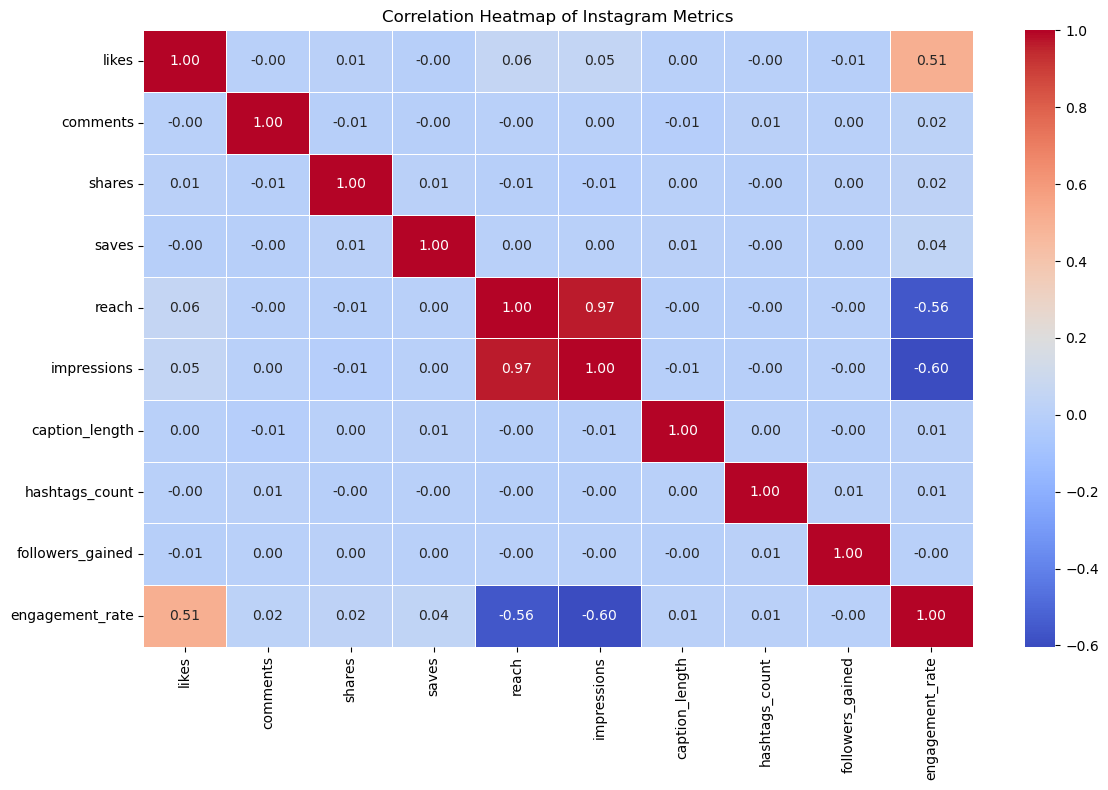

In [16]:
# Select numeric columns 
numeric_df = clean_insta_df.select_dtypes(include = 'number')

# compute correlation matrix 
corr_matrix = numeric_df.corr()

# plot heatmap 
plt.figure(figsize = (12, 8))
sns.heatmap(
    corr_matrix, 
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    linewidths = 0.5)

plt.title("Correlation Heatmap of Instagram Metrics")
plt.tight_layout()
plt.show()

As reach increases, impressions increases. These two variables have strong positive correlation. Engagement rate is moderately influenced by likes. They have moderate positive correlation. Comments, shares and saves contribute far less than expected. Engagement rate drops as reach and impression increase. High reach post and impressions tend to have lower engagement percentages. Broader audiences engage less proportionally. Comments, shares and save have weak influence on engagement rate. Their correlation with enagagement rate are near 0. Caption length and Hashtag do not matter much either. followers_gained donot show influence on engagement rate. 

# 2.6 Monthly Time Trends - Reach, Impressions, Engagement Rate,

In [70]:
# Extract year and month 
clean_insta_df['year'] = clean_insta_df['upload_date'].dt.year
clean_insta_df['month'] = clean_insta_df['upload_date'].dt.month
clean_insta_df.head()

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category,invalid_metrics_flag,year,month
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology,False,2024,11
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness,False,2025,8
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty,False,2025,9
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music,False,2025,9
5,IG0000006,2025-05-06 09:25:22.954916,Carousel,10500,7337,3601,5163,311157,381943,1448,12,904,Reels Feed,6.96,Photography,False,2025,5


In [71]:
# Group and aggregate 
monthly_stats = (clean_insta_df.groupby(['year', 'month']).agg(
    reach_mean = ('reach', 'mean'),
    reach_median = ('reach', 'median'),
    impression_mean = ('impressions', 'mean'),
    impression_median = ('impressions', 'median'),
    engagement_rate_mean = ('engagement_rate', 'mean'),
    engagement_rate_median = ('engagement_rate', 'median')).reset_index())
print(monthly_stats)
                 

    year  month    reach_mean  reach_median  impression_mean  \
0   2024     11  1.043920e+06     1034589.0     1.299140e+06   
1   2024     12  1.049906e+06     1043323.0     1.298824e+06   
2   2025      1  1.046745e+06     1048863.0     1.294520e+06   
3   2025      2  1.042444e+06     1047238.0     1.292328e+06   
4   2025      3  1.051314e+06     1048038.0     1.300704e+06   
5   2025      4  1.033135e+06     1025576.5     1.290585e+06   
6   2025      5  1.034196e+06     1018722.0     1.283265e+06   
7   2025      6  1.066119e+06     1075894.5     1.318746e+06   
8   2025      7  1.058014e+06     1051904.0     1.307094e+06   
9   2025      8  1.052646e+06     1045361.5     1.306346e+06   
10  2025      9  1.052130e+06     1068008.0     1.303792e+06   
11  2025     10  1.036455e+06     1035157.5     1.281835e+06   
12  2025     11  1.045801e+06     1018578.5     1.289085e+06   

    impression_median  engagement_rate_mean  engagement_rate_median  
0           1277477.5            

In [74]:
monthly_stats['year_month'] = (monthly_stats['year'].astype(str) + '-' + 
                               monthly_stats['month'].astype(str).str.zfill(2))
monthly_stats.head()

,year,month,reach_mean,reach_median,impression_mean,impression_median,engagement_rate_mean,engagement_rate_median,year_month
0,2024,11,1.043920e+06,1034589.0,1.299140e+06,1277477.5,11.068457,8.34,2024-11
1,2024,12,1.049906e+06,1043323.0,1.298824e+06,1282831.0,11.243078,8.76,2024-12
2,2025,1,1.046745e+06,1048863.0,1.294520e+06,1294122.0,11.497242,8.89,2025-01
3,2025,2,1.042444e+06,1047238.0,1.292328e+06,1291400.0,11.576809,8.81,2025-02
4,2025,3,1.051314e+06,1048038.0,1.300704e+06,1300078.0,11.487179,8.92,2025-03


# Reach - Mean vs Median 

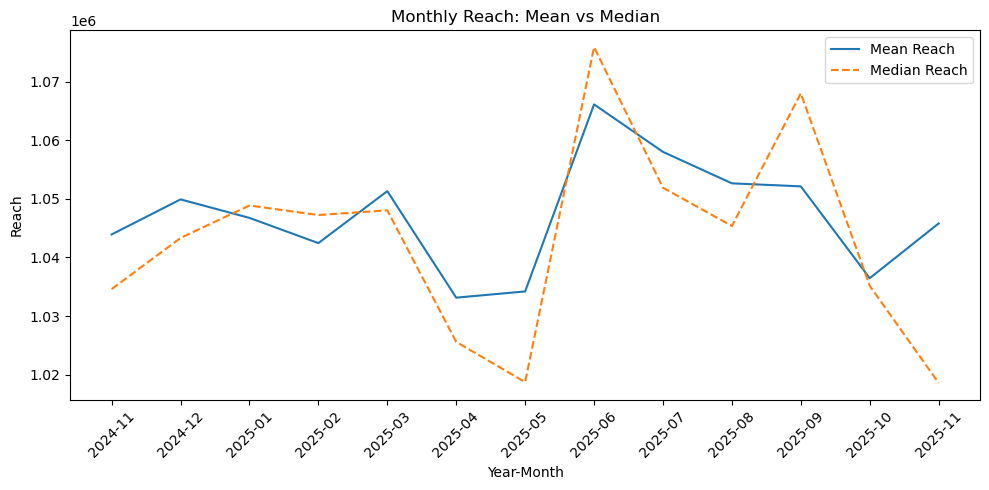

In [77]:
monthly_stats = monthly_stats.sort_values('year_month')
plt.figure(figsize = (10, 5))
plt.plot(monthly_stats['year_month'], monthly_stats['reach_mean'], label = 'Mean Reach')
plt.plot(monthly_stats['year_month'], monthly_stats['reach_median'], linestyle = '--', label = 'Median Reach')
plt.xlabel('Year-Month')
plt.ylabel('Reach')
plt.title('Monthly Reach: Mean vs Median')
plt.legend(loc = 'best')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Impressions - Mean vs Median 

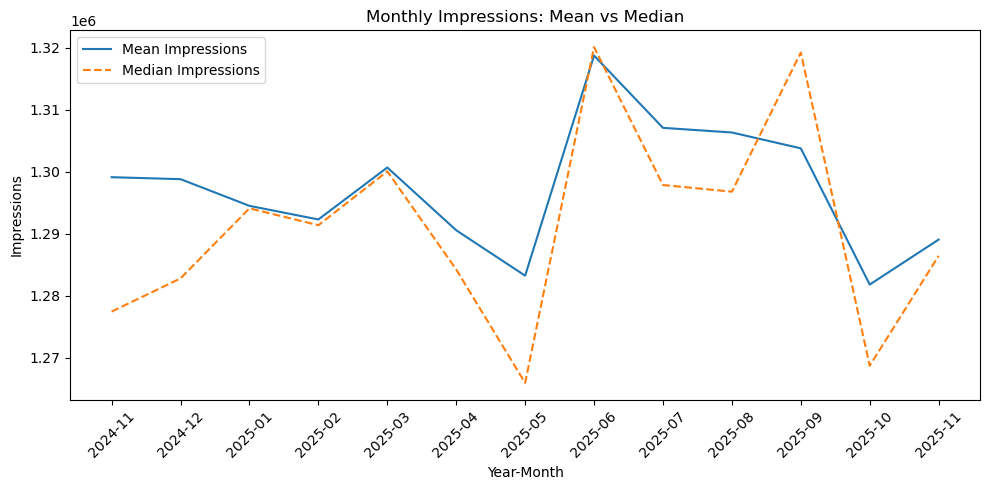

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_stats['year_month'], monthly_stats['impression_mean'], label='Mean Impressions')
plt.plot(monthly_stats['year_month'], monthly_stats['impression_median'], linestyle='--', label='Median Impressions')

plt.xlabel('Year-Month')
plt.ylabel('Impressions')
plt.title('Monthly Impressions: Mean vs Median')
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Engagement Rate - Mean vs Median 

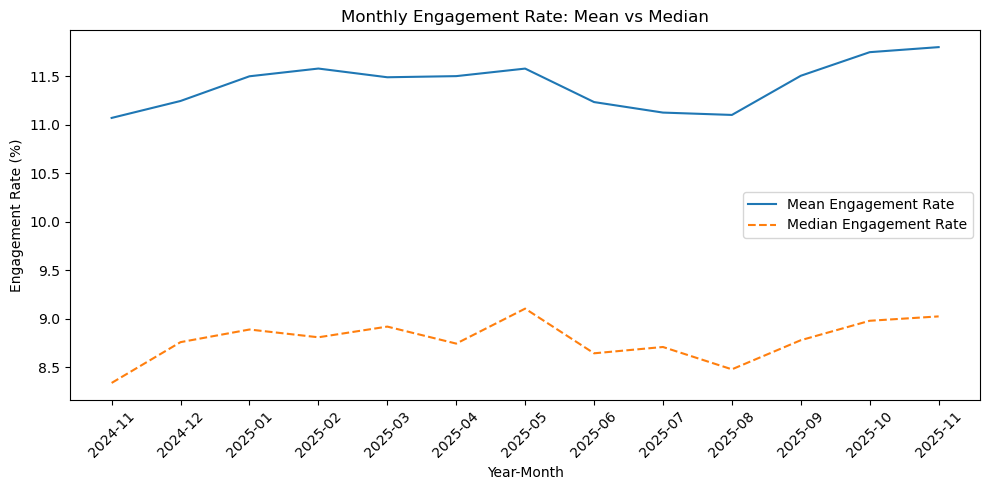

In [82]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_stats['year_month'], monthly_stats['engagement_rate_mean'], label='Mean Engagement Rate')
plt.plot(monthly_stats['year_month'], monthly_stats['engagement_rate_median'], linestyle='--', label='Median Engagement Rate')

plt.xlabel('Year-Month')
plt.ylabel('Engagement Rate (%)')
plt.title('Monthly Engagement Rate: Mean vs Median')
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly reach remains very stable, fluctuating within a narrow range (1.04M ~ 1.08M). The median closely follows the mean. A noticeable peak in June 2025 indicates above average reach for that month. 

Impressions show a pattern similar to reach but with slightly stronger variability. Median values stay close to the mean, again indicating low outlier distortion. A strong rise in June 2025 mirrors the reach spike suggesting a genuine performance boost rather than noise. Monthly impression trend track closely with reach trends. 

Engagement rate shows more month to month variation than reach or impressions. A clear upward trend appears from August to November 2025,indicating stronger audience interaction even wihtout major increases in reach. The dip in June-July shows that although reach was higher, engagement quality decreased in those months. 

June 2025 stands out with high reach and impressions but lower engagement rate. Possibly more viral content but weaker resonance. Late August thru Novemeber shows improving engagement rates, despite stable reach indicating more consistent better performing content. Since reach and impression remain  stable, improvement in enagagement rate are a strong sign of content quality improving not merely audience size. 


# 2.7 Categorical Analysis 

Now, this section compares categorical variables (media_type, traffic_source, content_category) across the instagram metrics: reach, impression, engagement_rate, likes and comments.

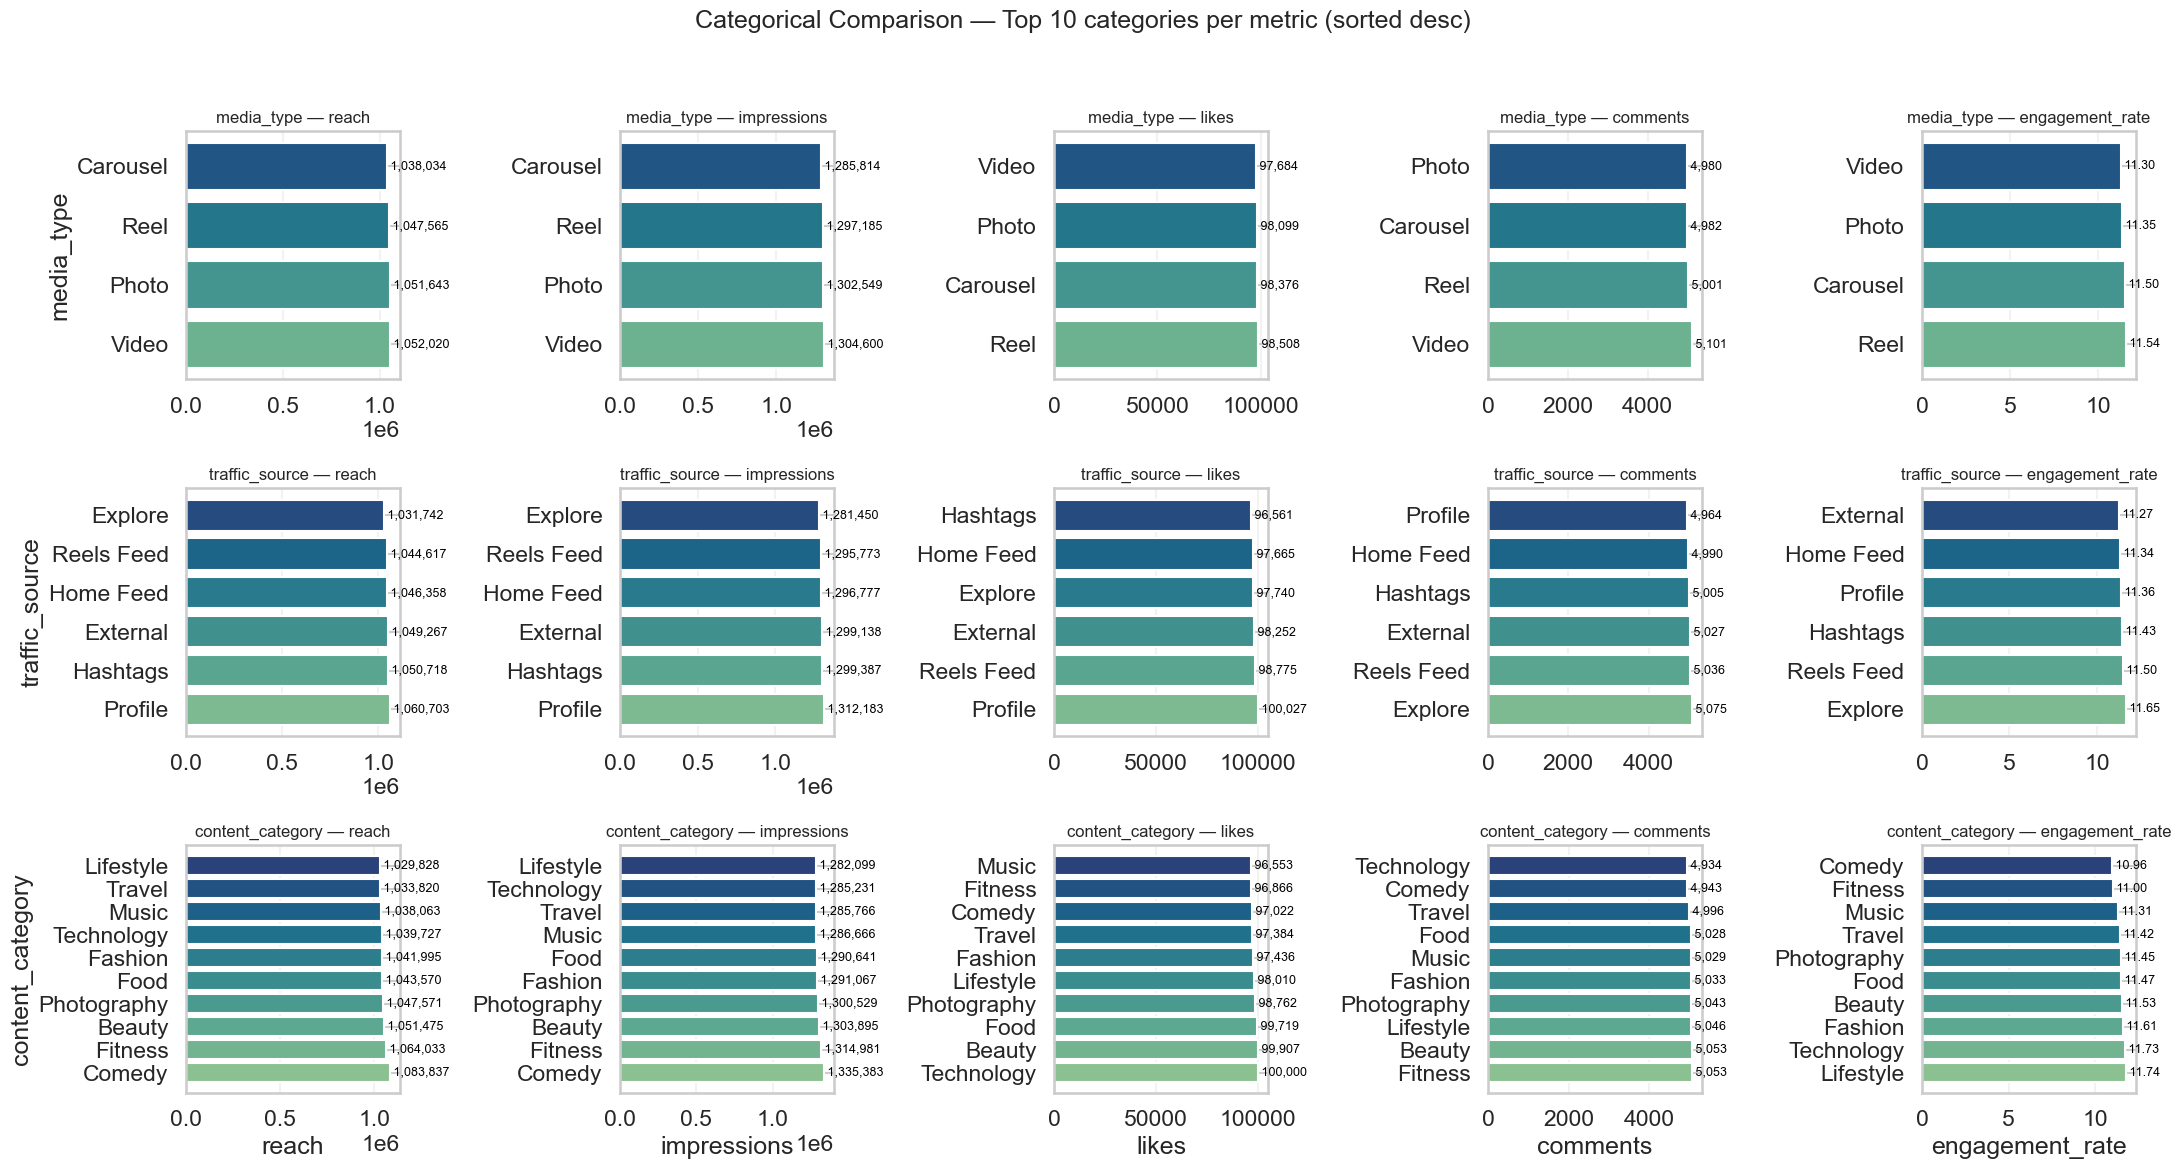

In [25]:
sns.set_context("talk")  # slightly larger fonts for presentation

# Configuration
categorical_vars = ['media_type', 'traffic_source', 'content_category']
metrics = ['reach', 'impressions', 'likes', 'comments', 'engagement_rate']
top_n = 10  # show top 10 categories per subplot for readability

# Prepare figure
fig, axes = plt.subplots(len(categorical_vars), len(metrics), figsize=(22, 12))
fig.suptitle("Categorical Comparison — Top 10 categories per metric (sorted desc)", fontsize=18, y=0.98)

# Loop through rows (categorical variables) and columns (metrics)
for i, cat in enumerate(categorical_vars):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]

        # Compute mean per category for this metric
        # use observed=True to avoid pandas FutureWarning about observed default change
        agg = clean_insta_df.groupby(cat, observed=True)[metric].mean().dropna()
        if agg.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_axis_off()
            continue

        # Select top N categories by mean
        top_series = agg.sort_values(ascending=False).head(top_n)
        top_idx = top_series.index.tolist()
        top_vals = top_series.values

        # Use matplotlib barh with a color palette to avoid seaborn palette warning
        colors = sns.color_palette('crest', n_colors=len(top_vals))
        ax.barh(y=top_idx, width=top_vals, color=colors)

        # Formatting
        ax.set_title(f"{cat} — {metric}", fontsize=12)
        if i == len(categorical_vars)-1:
            ax.set_xlabel(metric)
        else:
            ax.set_xlabel('')

        if j == 0:
            ax.set_ylabel(cat)
        else:
            ax.set_ylabel('')

        # Add value labels to the bars (right side)
        for k, v in enumerate(top_vals):
            label = f"{v:,.0f}" if metric not in ['engagement_rate'] else f"{v:.2f}"
            ax.text(v, k, f" {label}", va='center', fontsize=9, color='black')

        ax.grid(axis='x', alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

1. Media type Insights
 - Reach and Impression:  All formats (Carousel, Photo, Reel, Video) have nearly the same reach and impressions
 -  Likes and Comments: Reel slighlty lead in likes and Video lead slightly in comments
 - Enagagement rate: Reels and Carousel have slighlty higher engagement rate than other.
2. Traffic Source
 - Reach and Impression: Profile visit generate the highest reach. Explore has marginally lower reach compared to other sources.
 - Likes and Comments: Profile and Explore posts perform moderately better than sources
 - Enagagement rate: Explore and Reels Feed bring the highest engagement rates. External     traffic sources generate the weakest engagement.
3. Content category
 - Reach and Impression: Comedy and Fitness perform best Travel and technology lag slightly
 - Likes and comments: Technology, fitness and beauty generates highest likes and comments compared to other category
 - Engagement rate: The rate varies much more by content type than by format. Lifestyle generate highest engagement rate followed by techonolgy.

Key takeways:
- Reach and Impression are fairly stable across media type and sources. Engagement metrics (like, comments, engagement rate) reveal real differences. Content category has the strongest impact on performance. 

Key Performing Categories
- Reels -- highest likes and strong engagement 
- Explore -- highest engagement and profile highest reach, impression and likes
- Technology/lifestyle/fitness/Beauty are top performing content driving higher engagement,reach,
impression, likes and comments 
